Mean reversion is the concept of stocks (in this case) returning back towards their historical average (the "mean).
As in, if a stock starts to peak up or crash down, mean reversion says it will eventually return back towards that average, unless something fundamental has changed.

Why does mean reversion happen:
- markets overreact to news
- investor psychology causes prices to swing too far
- eventually fundamentals (earnings, growth, etc.) may pull prices back toward normal levels

Applications:
- pairs trading (done with 2 stocks that usually move together, knowing that no matter how far one stock goes, the other will eventually catch up)
- statistical arbitrage (similar to pair trading but instead of a "pair" of stocks, you are looking at a bunch of stocks)
- boilinger bands (technical analysis) (bands get wider when prices are volatile, and get narrower when prices are calm) (help traders see when a stok might be too high or too low compared to its normal behavior)
- value investing (buying a really good stock when the price is low)

In [24]:
# importing necessary modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

# make sure plots show inside notebook
%matplotlib inline

In [25]:
# 2 of the most-wdiely traded ETF's in the U.S:
# - SPY (SPDR S&P 500 ETF Trust): tracks the perfromance of the S&P 500 Index
# - QQQ (Invesco QQQ Trust): tracks the performance of the Nasdaq-100 Index)

# define tickers (setting up the 2 ETF's) (exhange-traded funds) 
tickers = ['SPY', 'QQQ']

# download full data
data = yf.download(tickers, start='2015-01-01', end='2024-06-04', auto_adjust=True)

# extract just 'Adj Close' using pandas .loc with MultiIndex columns
adj_close = data['Close']

[*********************100%***********************]  2 of 2 completed


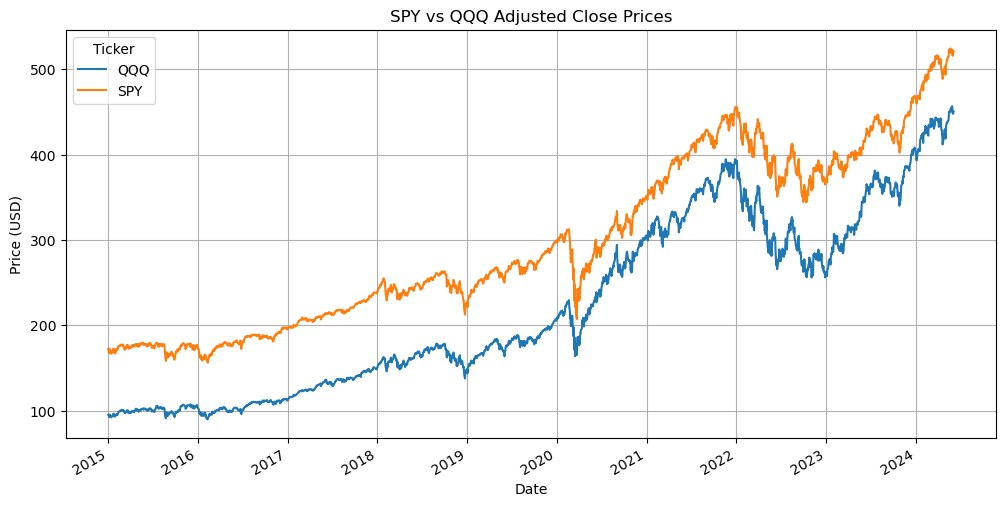

In [26]:
# make graph comparing SPY and QQQ
adj_close.plot(figsize=(12,6), title='SPY vs QQQ Adjusted Close Prices')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.show()

In [27]:
#1. compute the spread (the difference between the SPY line and the QQQ line)
spread = adj_close['SPY'] - adj_close['QQQ']

#2. calculate the the mean (average) and the std for the past lookback days
lookback = 60
rolling_mean = spread.rolling(window=lookback).mean()
rolling_std = spread.rolling(window=lookback).std()
    
#3. compute z-score
zscore = (spread - rolling_mean) / rolling_std

# quick check:L show head of each series
pd.DataFrame({
    'SPY-QQQ Spread': spread, 
    'Rolling Mean': rolling_mean, 
    'Rolling Std': rolling_std,
    'Z-Score': zscore
}).dropna().head()

,SPY-QQQ Spread,Rolling Mean,Rolling Std,Z-Score
Date,,,,
2015-03-30,76.363701,75.900390,0.853314,0.542955
2015-03-31,75.878990,75.882507,0.842073,-0.004177
2015-04-01,75.774200,75.891416,0.837974,-0.139880
2015-04-02,76.331978,75.915201,0.829710,0.502316
2015-04-06,76.704979,75.930308,0.835780,0.926883


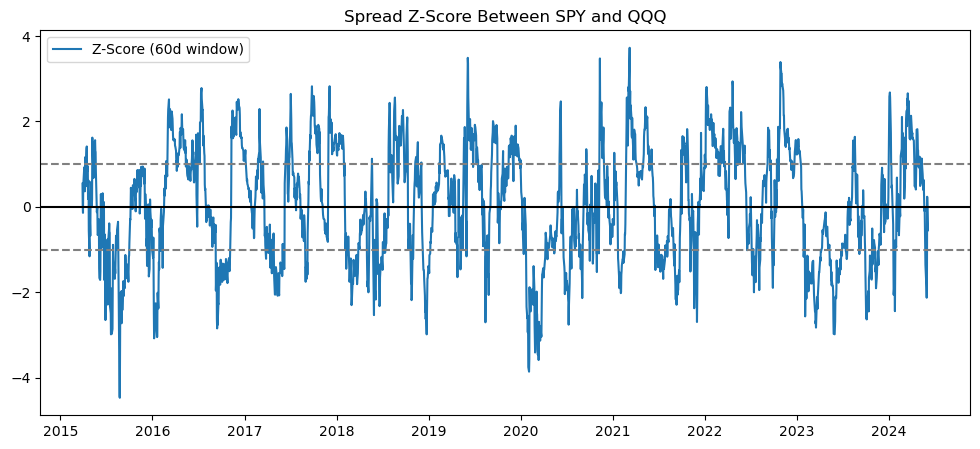

In [28]:
#* now visualize the table above into 3 graphs

plt.figure(figsize=(12,5))
plt.plot(spread.index, zscore, label='Z-Score (60d window)')
plt.axhline( 1.0, color='grey', linestyle='--') # upper threshold
plt.axhline( 0.0, color='black', linestyle='-') # mean
plt.axhline(-1.0, color='grey', linestyle='--') # lower threshold
plt.legend()
plt.title('Spread Z-Score Between SPY and QQQ')
plt.show()

now we'll generate trading signals and backtest by using a classic mean-reversion rule:
- long the spread (long SPY, short QQQ) when z <= -1
- exit (flat) when z >= 0
- short the spread (short SPY, long QQQ) when z >= 1
- exit when z <= 0

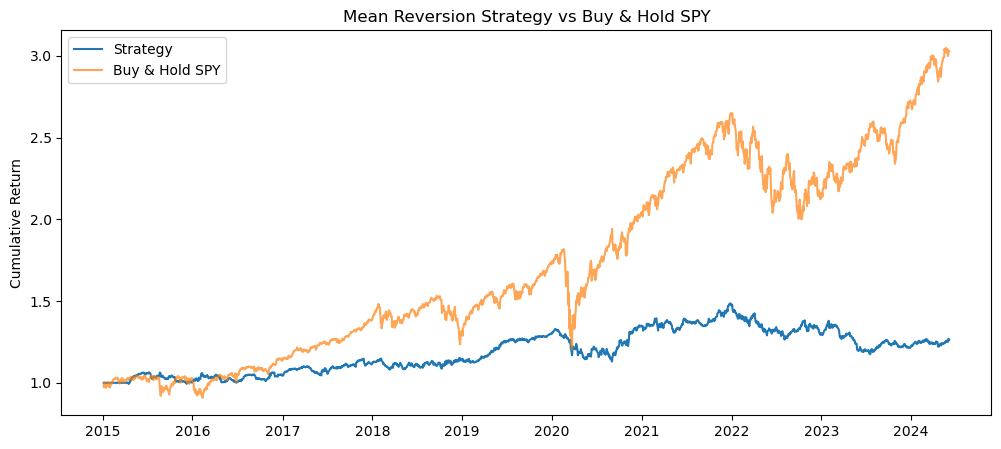

In [29]:
#1. calculate daily returns
ret_spy = adj_close['SPY'].pct_change()
ret_qqq = adj_close['QQQ'].pct_change()

#2. build signal series: 1 = long spread, -1 = short spread, 0 = flat
signal = pd.Series(0, index=zscore.index)
signal[zscore <= -1] = 1  # enter long
signal[zscore >= 1] = -1  # enter short

#3. apply a simple "exit to zero" rule whenever z crosses back through 0, go to flat
signal[(zscore.shift() < 0) & (zscore >= 0)] = 0
signal[(zscore.shift() > 0) & (zscore <= 0)] = 0

#4. forward-fill positions so we hold until exit
positions = signal.where(signal != 0).ffill().fillna(0)

#5. strategy returns:
# if position = 1: ret_spy - ret_qqq
# if position = -1: -(ret_spy - ret_qqq)
strat_ret = positions.shift() * (ret_spy - ret_qqq)

#6. compute cumulative returns
cum_strat = (1 + strat_ret.dropna()).cumprod()

#7. plot performance vs buy-and-old SPY
plt.figure(figsize=(12,5))
plt.plot(cum_strat, label='Strategy')
plt.plot((1+ret_spy.dropna()).cumprod(), label='Buy & Hold SPY', alpha=0.7)
plt.title('Mean Reversion Strategy vs Buy & Hold SPY')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

In [30]:
def compute_performance(returns, freq=252):
    r = returns.dropna()
    # compound annual growth rate
    total_days = (r.index[-1] - r.index[0]).days
    cagr = (1 + r).prod() ** (365.0/total_days) - 1

    # annualized volatility
    vol = r.std() * np.sqrt(freq)

    # sharpe (0% RF)
    sharpe = cagr / vol if vol else np.nan

    # max drawdown
    cum = (1 + r).cumprod()
    peak = cum.cummax()
    mdd = ((cum-peak) / peak).min()
    return{
    'CAGR': cagr,
    'Volatility': vol,
    'Sharpe': sharpe,
    'Max Drawdown': mdd

    }

# compute and print
strat_metrics = compute_performance(strat_ret)
bh_metrics = compute_performance(ret_spy)

print("Strategy Performance: ", strat_metrics)
print("\nBuy & Hold SPY: ", bh_metrics)

Strategy Performance:  {'CAGR': np.float64(0.02515768379009331), 'Volatility': np.float64(0.08470025219301863), 'Sharpe': np.float64(0.2970201757222975), 'Max Drawdown': -0.20918280800014824}

Buy & Hold SPY:  {'CAGR': np.float64(0.1248855190060636), 'Volatility': np.float64(0.1784504559091447), 'Sharpe': np.float64(0.699833006140635), 'Max Drawdown': -0.33717280153771284}


In [31]:
# run this when testing what time frame you're running your paper trading

# print("Date range in `data`:", data.index.min(), "to", data.index.max())
# adj_close = data['Close']
# print("Date range in `adj_close`:", adj_close.index.min(), "to", adj_close.index.max())

In [32]:
#1. set a per-trade cost (5 bps round-trip)
cost_per_trade = 0.0005

#2. count trades as changes in position
trades = positions.diff().abs()

#3. compute transaction-cost series
tc = trades * cost_per_trade

#4. net strategy returns after cpsts
strat_ret_tc = strat_ret - tc

#5. recompute metrics
tc_metrics = compute_performance(strat_ret_tc)

print("Strategy w/ 5bp Costs:", tc_metrics)

Strategy w/ 5bp Costs: {'CAGR': np.float64(0.020023136713496426), 'Volatility': np.float64(0.08442829730361781), 'Sharpe': np.float64(0.2371614417555999), 'Max Drawdown': -0.21310233973088075}


In [54]:
# grabs SPY/QQQ prices and returns a simple DataFrame of their adjusted closes
def download_data(tickers, start, end):
    df = yf.download(tickers, start=start, end=end, auto_adjust=True)
    return df['Close']

# given those prices and the arguments passed through the function, this cimputes the spread, 
# rolling mean/std, builds a -+1 signals (with proper .loc[...] so pandas doesn't warn, forward-fills so 
# you hold the fund until you cross back through zero to prevent loss.

# also takes the positions Series and the price DataFrame and computs daily strategy returns vs SPY returns
# for any return series, calculates CAGR, annualized volatility, Sharpe, and max drawdown
def generate_positions(adj_close, lookback, entry_z):
    spread = adj_close['SPY'] - adj_close['QQQ']
    m = spread.rolling(lookback).mean()
    s = spread.rolling(lookback).std()
    zsc = (spread - m) / s

    sig = pd.Series(0, index=zsc.index)
    # use .loc to avoid the deprecation warning
    sig.loc[zsc <= -entry_z] = 1
    sig.loc[zsc >=  entry_z] = -1
    sig.loc[(zsc.shift() < 0) & (zsc >= 0)] = 0
    sig.loc[(zsc.shift() > 0) & (zsc <= 0)] = 0

    # forward-fill and fill initial NaNs
    return sig.where(sig != 0).ffill().fillna(0)

def backtest(adj_close, positions):
    ret_spy = adj_close['SPY'].pct_change()
    ret_qqq = adj_close['QQQ'].pct_change()
    strat = positions.shift() * (ret_spy - ret_qqq)
    return strat.dropna(), ret_spy.dropna()

def compute_metrics(strat_ret, bh_ret, freq=252):
    def perf(r):
        r = r.dropna()
        days = (r.index[-1] - r.index[0]).days
        cagr = (1 + r).prod() ** (365.0/days) - 1
        vol = r.std() * np.sqrt(freq)
        sharpe = cagr/vol if vol else np.nan
        cum = (1 + r).cumprod()
        dd = (cum - cum.cummax())/cum.cummax()
        mdd = dd.min()
        return cagr, vol, sharpe, mdd
    return perf(strat_ret), perf(bh_ret)

In [55]:
# here we run a parameter grid search where its looped over a small grid of lookbacks days and entry 
# thresholds. For each (lookback, entry_z) pair we generated the trading positions, backtested the stregy 
# vs buy-&-hold SPY, computed performance metrics for each, appended those results into a list of dicts
# and converted that list into a DataFrame called grid which is then sorted by the strat_Sharpe column we
# added, so we can immediately see which parameter combinations gave the highest risk-adjusted return

# download once
adj = download_data(['SPY','QQQ'], '2015-01-01','2024-06-01')

results = []
for lookback in [20, 40, 60, 120]:
    for entry_z in [0.5, 1.0, 1.5]:
        pos = generate_positions(adj, lookback, entry_z)
        strat_ret, bh_ret = backtest(adj, pos)
        (c_s, v_s, sr_s, dd_s), (c_b, v_b, sr_b, dd_b) = compute_metrics(strat_ret, bh_ret)

        results.append({
            'lookback': lookback,
            'entry_z': entry_z,
            'strat_CAGR': c_s,
            'strat_Sharpe': sr_s,
            'strat_Drawdown': dd_s,
            'bh_CAGR': c_b,
            'bh_Sharpe': sr_b,
            'bh_Drawdown': dd_b
        })

grid = pd.DataFrame(results)
grid.sort_values('strat_Sharpe', ascending=False).head(10)

[*********************100%***********************]  2 of 2 completed


,lookback,entry_z,strat_CAGR,strat_Sharpe,strat_Drawdown,bh_CAGR,bh_Sharpe,bh_Drawdown
8,60,1.5,0.041168,0.487433,-0.151839,0.124904,0.699787,-0.337173
4,40,1.0,0.032255,0.380141,-0.255615,0.124904,0.699787,-0.337173
5,40,1.5,0.028481,0.335643,-0.203050,0.124904,0.699787,-0.337173
7,60,1.0,0.025677,0.303136,-0.209183,0.124904,0.699787,-0.337173
6,60,0.5,0.025019,0.295266,-0.262431,0.124904,0.699787,-0.337173
2,20,1.5,0.023790,0.279885,-0.253745,0.124904,0.699787,-0.337173
1,20,1.0,0.022083,0.259796,-0.292360,0.124904,0.699787,-0.337173
0,20,0.5,0.021269,0.250223,-0.260896,0.124904,0.699787,-0.337173
10,120,1.0,0.017770,0.210537,-0.202288,0.124904,0.699787,-0.337173
3,40,0.5,0.017183,0.202465,-0.246822,0.124904,0.699787,-0.337173


In [56]:
grid.sort_values('strat_Sharpe', ascending=False).head(10).style.format({
    'strat_CAGR': '{:.2%}',
    'strat_Sharpe': '{:.2f}',
    'strat_Drawdown': '{:.1%}'
})

,lookback,entry_z,strat_CAGR,strat_Sharpe,strat_Drawdown,bh_CAGR,bh_Sharpe,bh_Drawdown
8,60,1.500000,4.12%,0.49,-15.2%,0.124904,0.699787,-0.337173
4,40,1.000000,3.23%,0.38,-25.6%,0.124904,0.699787,-0.337173
5,40,1.500000,2.85%,0.34,-20.3%,0.124904,0.699787,-0.337173
7,60,1.000000,2.57%,0.30,-20.9%,0.124904,0.699787,-0.337173
6,60,0.500000,2.50%,0.30,-26.2%,0.124904,0.699787,-0.337173
2,20,1.500000,2.38%,0.28,-25.4%,0.124904,0.699787,-0.337173
1,20,1.000000,2.21%,0.26,-29.2%,0.124904,0.699787,-0.337173
0,20,0.500000,2.13%,0.25,-26.1%,0.124904,0.699787,-0.337173
10,120,1.000000,1.78%,0.21,-20.2%,0.124904,0.699787,-0.337173
3,40,0.500000,1.72%,0.20,-24.7%,0.124904,0.699787,-0.337173


In [57]:
grid.head(10).style.format({
    'strat_CAGR': '{:.2%}',
    'strat_Sharpe': '{:.2f}',
    'strat_Drawdown': '{:.1%}',
    'bh_CAGR': '{:.2%}',
    'bh_Sharpe': '{:.2f}',
    'bh_Drawdown': '{:.1%}'
})

,lookback,entry_z,strat_CAGR,strat_Sharpe,strat_Drawdown,bh_CAGR,bh_Sharpe,bh_Drawdown
0,20,0.500000,2.13%,0.25,-26.1%,12.49%,0.70,-33.7%
1,20,1.000000,2.21%,0.26,-29.2%,12.49%,0.70,-33.7%
2,20,1.500000,2.38%,0.28,-25.4%,12.49%,0.70,-33.7%
3,40,0.500000,1.72%,0.20,-24.7%,12.49%,0.70,-33.7%
4,40,1.000000,3.23%,0.38,-25.6%,12.49%,0.70,-33.7%
5,40,1.500000,2.85%,0.34,-20.3%,12.49%,0.70,-33.7%
6,60,0.500000,2.50%,0.30,-26.2%,12.49%,0.70,-33.7%
7,60,1.000000,2.57%,0.30,-20.9%,12.49%,0.70,-33.7%
8,60,1.500000,4.12%,0.49,-15.2%,12.49%,0.70,-33.7%
9,120,0.500000,-0.34%,-0.04,-24.0%,12.49%,0.70,-33.7%


In [58]:
# this will give us the highest Sharpe
best = grid.loc[grid['strat_Sharpe'].idxmax()]
best

lookback          60.000000
entry_z            1.500000
strat_CAGR         0.041168
strat_Sharpe       0.487433
strat_Drawdown    -0.151839
bh_CAGR            0.124904
bh_Sharpe          0.699787
bh_Drawdown       -0.337173
Name: 8, dtype: float64

In [60]:
# this will give us the top 3 candidates which will also meet our drawdown tolerance ensuring its not too 
# high (a high drawdown will cause us to lose more money at the lowest point in our investing)

good = grid[(grid['strat_Sharpe'] >= 0.30) & (grid['strat_Drawdown'] >= -0.25)]
good.sort_values('strat_Sharpe', ascending=False).head()

,lookback,entry_z,strat_CAGR,strat_Sharpe,strat_Drawdown,bh_CAGR,bh_Sharpe,bh_Drawdown
8,60,1.5,0.041168,0.487433,-0.151839,0.124904,0.699787,-0.337173
5,40,1.5,0.028481,0.335643,-0.203050,0.124904,0.699787,-0.337173
7,60,1.0,0.025677,0.303136,-0.209183,0.124904,0.699787,-0.337173
